# Heart Failure Prediction with PyTorch

Binary classification to predict heart disease using a fully-connected neural network.

**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) by fedesoriano on Kaggle.

## 1. Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## 2. Load Data

In [10]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv


In [11]:
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv')

## 3. Exploratory Data Analysis

In [12]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [14]:
print('Class distribution:')
print(df['HeartDisease'].value_counts())
print(f'\nClass balance: {df["HeartDisease"].mean():.2%} positive')

Class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Class balance: 55.34% positive


## 4. Preprocessing

In [15]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (734, 11), Test size: (184, 11)


## 5. PyTorch Dataset & DataLoader

In [16]:
class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.to_numpy() if hasattr(y, 'to_numpy') else y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = HeartDataset(X_train, y_train)
test_dataset  = HeartDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

## 6. Model Architecture

Two models trained side-by-side to compare the effect of **Dropout** on training stability and generalisation.

In [17]:
class HeartModel(nn.Module):
    def __init__(self, input_features, use_dropout=True):
        super().__init__()
        layers = [
            nn.Linear(input_features, 32),
            nn.ReLU(),
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.3))
        layers += [
            nn.Linear(32, 16),
            nn.ReLU(),
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.3))
        layers += [nn.Linear(16, 1), nn.Sigmoid()]
        self.network = nn.Sequential(*layers)

    def forward(self, X):
        return self.network(X)

## 7. Training

In [18]:
def train_model(use_dropout, epochs=50):
    model = HeartModel(train_dataset.X.shape[1], use_dropout=use_dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()
    loss_history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch.view(-1, 1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    return model, loss_history


model_with_dropout,    loss_with_dropout    = train_model(use_dropout=True)
model_without_dropout, loss_without_dropout = train_model(use_dropout=False)
print('Training complete.')

Training complete.


## 8. Loss Curves

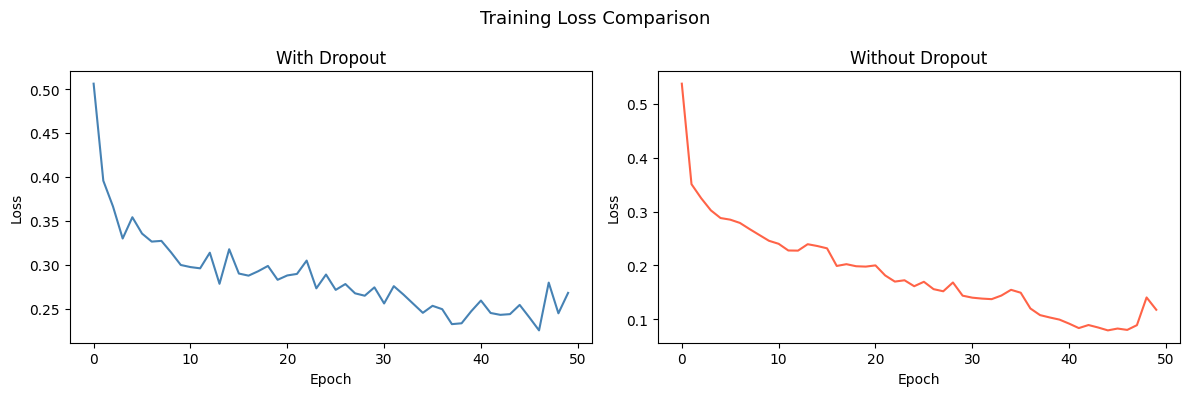

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_with_dropout, color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('With Dropout')

ax2.plot(loss_without_dropout, color='tomato')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Without Dropout')

plt.suptitle('Training Loss Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluation

In [20]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = (model(X_batch) > 0.5).float().squeeze()
            correct += (y_pred == y_batch).float().sum().item()
            total += len(y_batch)
    return correct / total


acc_dropout    = evaluate(model_with_dropout,    test_loader)
acc_no_dropout = evaluate(model_without_dropout, test_loader)

print(f'Accuracy (with dropout):    {acc_dropout:.4f}')
print(f'Accuracy (without dropout): {acc_no_dropout:.4f}')

Accuracy (with dropout):    0.8478
Accuracy (without dropout): 0.8098
